<a href="https://colab.research.google.com/github/tadisetti-dp/CodeAlpha_Data_Analytics/blob/main/CodeAlpha_Data_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CodeAlpha Internship Project
## Superstore Data Analysis - Target Variable: Sales

**Tasks Covered:**
- Task 1: Exploratory Data Analysis (EDA) focused on Sales
- Task 2: Data Visualization with Sales as the target


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set standard style for visualizations
sns.set_theme(style="whitegrid", palette="muted")

###  Loading the Superstore Sales Dataset

In [ ]:
try:
    df = pd.read_csv('/content/SuperStore Sales Dataset.csv', encoding='utf-8')
    print("Superstore Sales Dataset loaded successfully!")
except UnicodeDecodeError:
    print("UnicodeDecodeError: Trying with 'latin1' encoding.")
    try:
        df = pd.read_csv('/content/SuperStore Sales Dataset.csv', encoding='latin1')
        print("Superstore Sales Dataset loaded successfully with latin1 encoding!")
    except Exception as e:
        print(f"Error loading dataset with latin1 encoding: {e}")
except FileNotFoundError:
    print("File not found. Please upload the 'Superstore_Sales_Dataset.csv' file to Google Colab.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Superstore Sales Dataset loaded successfully!


## Task 1: Exploratory Data Analysis (EDA)
Understanding our variables and data layout with a specific focus on **Sales**.


In [ ]:
# Displaying the first few rows
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [ ]:
# Checking the shape and information of the dataset
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()

Dataset Shape: (51290, 21)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  fl

In [ ]:
# Cleaning: Checking for missing values and duplicates
print("Missing Values:\n", df.isnull().sum())
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicated rows: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Shape after dropping duplicates: {df.shape}")

Missing Values:
 order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

Number of duplicated rows: 0


### 🎯 Analyzing the Target Variable: Sales
Since `Sales` is our target variable, we need to inspect its statistical properties.

In [ ]:
# Statistical Summary of Sales (Target Column)
print(df['sales'].describe())

count     51290
unique     2246
top          13
freq        589
Name: sales, dtype: object


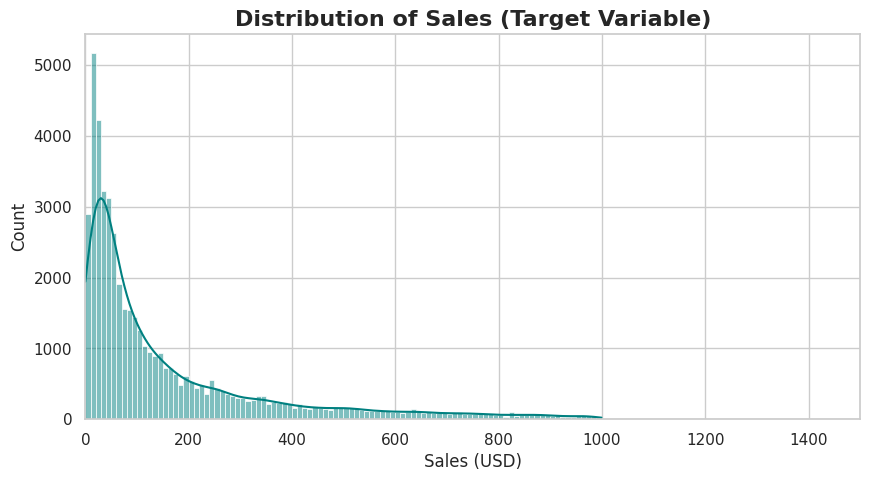

In [ ]:
# Convert 'sales' to numeric, coercing errors to NaN
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')

# Drop rows where 'sales' is NaN after conversion (if any non-numeric values were present)
df.dropna(subset=['sales'], inplace=True)

# Distribution Plot for Sales
plt.figure(figsize=(10, 5))
sns.histplot(df['sales'], bins=100, kde=True, color='teal')
plt.title('Distribution of Sales (Target Variable)', fontsize=16, weight='bold')
plt.xlabel('Sales (USD)')
plt.xlim(0, 1500) # Limiting x-axis due to heavy right-skew of sales data
plt.show()

## Task 2: Data Visualization
How do different features relate to our target variable: **Sales**?


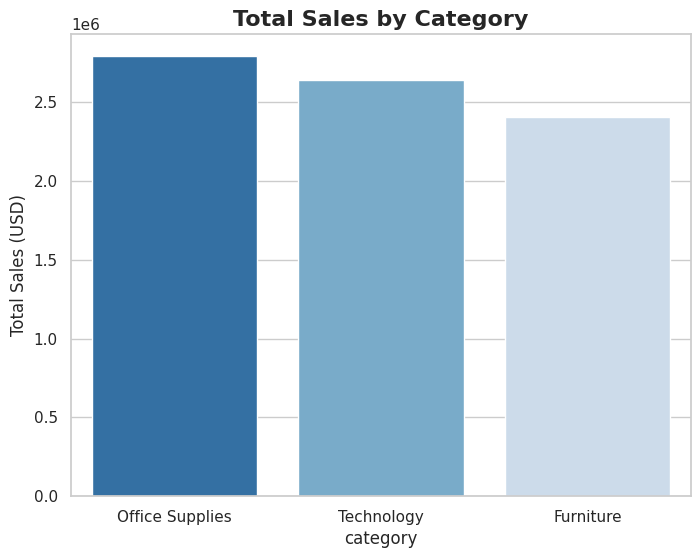

In [ ]:
# 1. Total Sales by Category
plt.figure(figsize=(8, 6))
category_sales = df.groupby('category')['sales'].sum().sort_values(ascending=False)
sns.barplot(x=category_sales.index, y=category_sales.values, palette='Blues_r')
plt.title('Total Sales by Category', fontsize=16, weight='bold')
plt.ylabel('Total Sales (USD)')
plt.show()

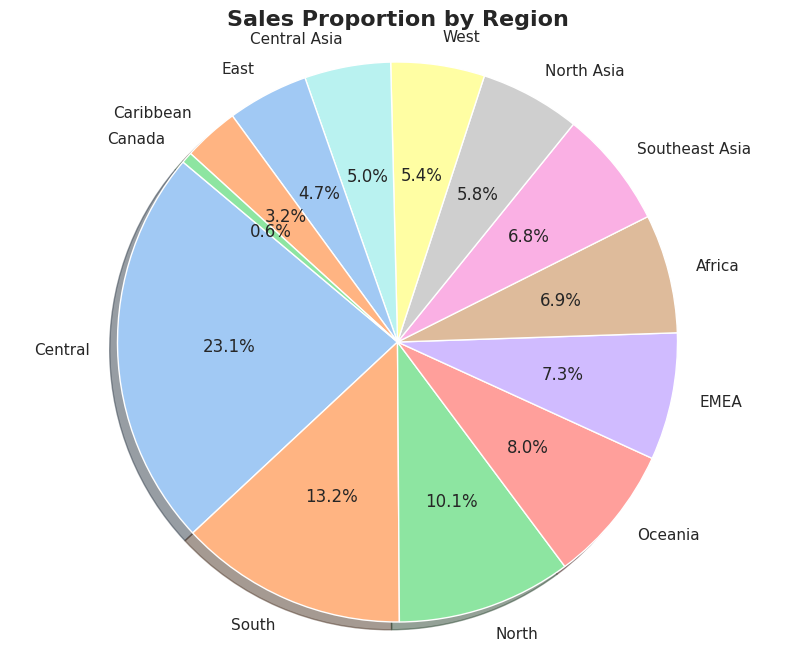

In [ ]:
# 2. Total Sales by Region
plt.figure(figsize=(10, 8))
# Aggregating sales by region using the correct lowercase column names
region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)

# Creating the pie chart
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('pastel'), shadow=True)

plt.title('Sales Proportion by Region', fontsize=16, weight='bold')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

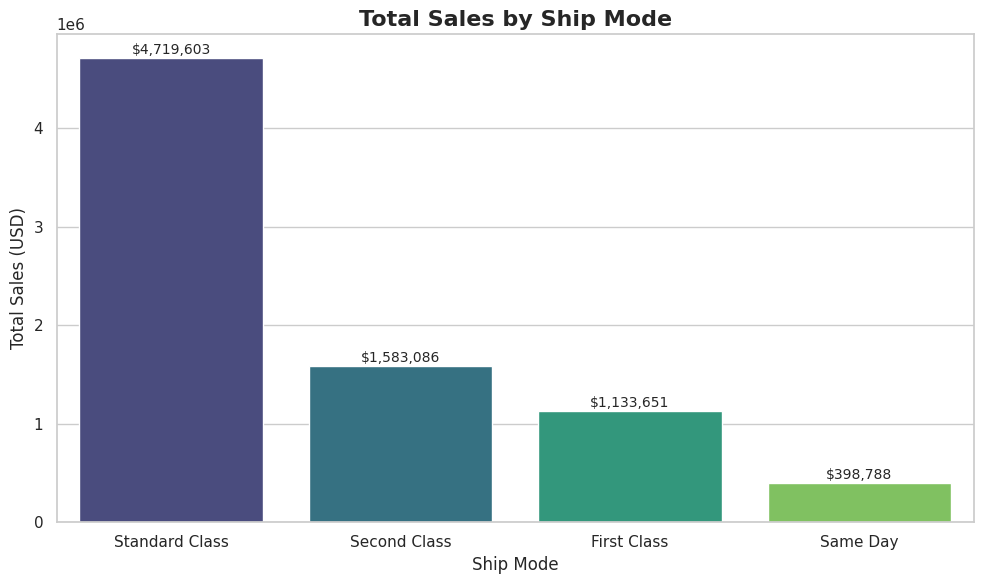

In [ ]:
# 3. Total Sales by Ship Mode
plt.figure(figsize=(10, 6))
ship_mode_sales = df.groupby('ship_mode')['sales'].sum().sort_values(ascending=False)

sns.barplot(x=ship_mode_sales.index, y=ship_mode_sales.values, palette='viridis')
plt.title('Total Sales by Ship Mode', fontsize=16, weight='bold')
plt.xlabel('Ship Mode')
plt.ylabel('Total Sales (USD)')

# Adding labels on top of bars
for i, v in enumerate(ship_mode_sales.values):
    plt.text(i, v + 10000, f'${v:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

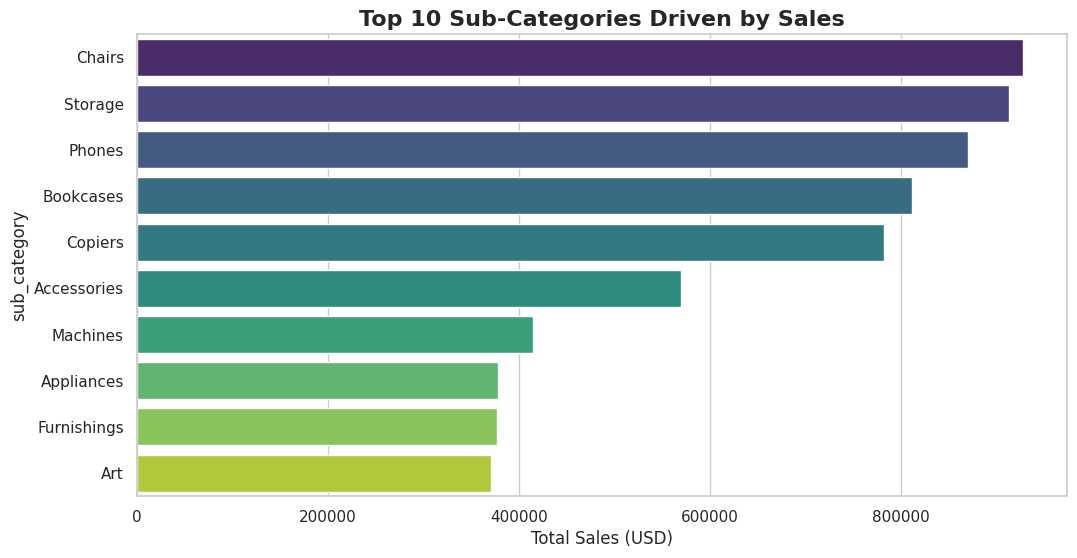

In [ ]:
# 3. Top 10 Sub-Categories by Sales
plt.figure(figsize=(12, 6))
# Fixing column names to lowercase 'sub_category' and 'sales'
sub_category_sales = df.groupby('sub_category')['sales'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=sub_category_sales.values, y=sub_category_sales.index, palette='viridis')
plt.title('Top 10 Sub-Categories Driven by Sales', fontsize=16, weight='bold')
plt.xlabel('Total Sales (USD)')
plt.show()

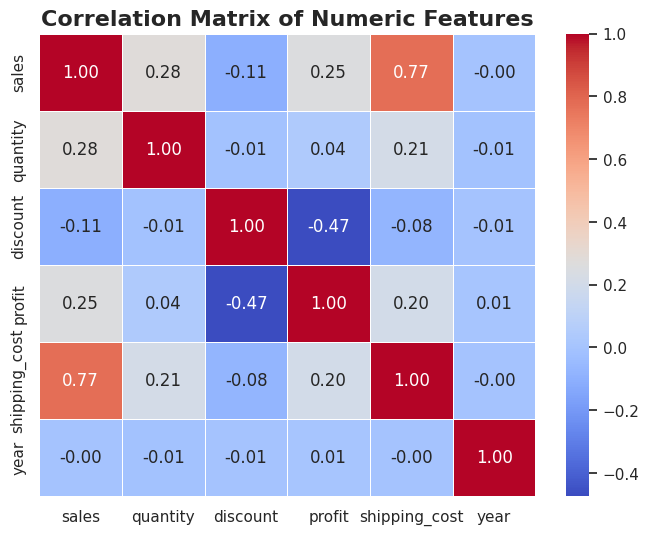

Correlation with Target Variable (sales):
 sales            1.000000
shipping_cost    0.771133
quantity         0.276072
profit           0.252703
year            -0.002479
discount        -0.106719
Name: sales, dtype: float64


In [ ]:
# 4. Correlation Matrix focusing on Sales
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numeric Features', fontsize=16, weight='bold')
plt.show()

# Correcting 'Sales' to 'sales' to match the column name in the dataframe
print("Correlation with Target Variable (sales):\n", correlation['sales'].sort_values(ascending=False))

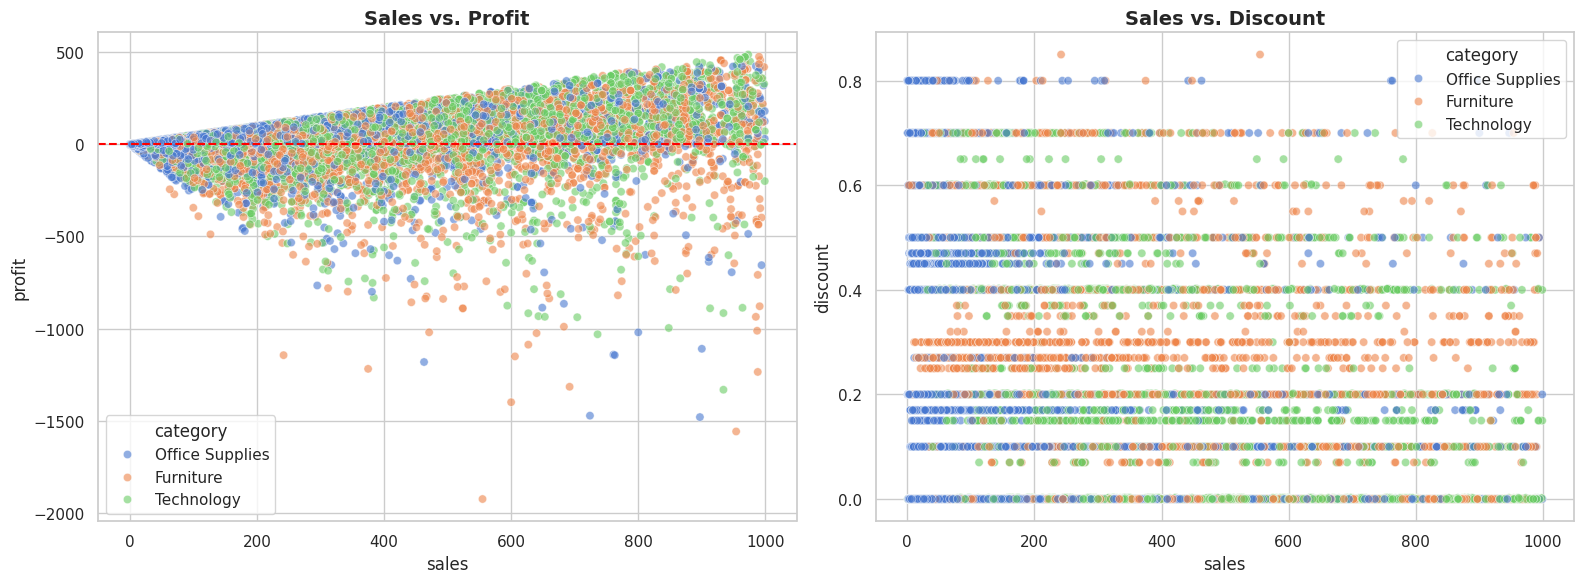

In [ ]:
# 5. Relationship: Sales vs Discount and Profit
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Sales vs Profit - Using lowercase column names
sns.scatterplot(x='sales', y='profit', data=df, hue='category', alpha=0.6, ax=ax[0])
ax[0].set_title('Sales vs. Profit', fontsize=14, weight='bold')
ax[0].axhline(0, color='red', linestyle='--') # Red line indicating break-even

# Sales vs Discount - Using lowercase column names
sns.scatterplot(x='sales', y='discount', data=df, hue='category', alpha=0.6, ax=ax[1])
ax[1].set_title('Sales vs. Discount', fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

### 💡 Key Insights based on Target Variable (`Sales`):
1. **Sales Skewness**: The target variable `Sales` is highly right-skewed, meaning the majority of transactions are relatively small, with a few massive enterprise-level orders making up the tail.
2. **Category Performance**: `Technology` leads in driving overall Sales, followed closely by Furniture. However, the correlation matrix and scatterplot show that higher sales in furniture often face major discounts resulting in profit hits.
3. **Sub-Categories**: `Phones` and `Chairs` are the top performing sub-categories regarding gross Sales.
4. **Region**: The Western region contributes roughly a third (~32%) of total company Sales.
5. **Correlation Factors**: The target variable `Sales` is highly positively correlated with `Profit`, demonstrating that larger sales volumes typically mean a higher margin—unless countered by large `Discount` values as shown in the scatterplot